### Imports and Configuration


In [1]:
# Import shared libraries, metrics, and utilities used across the full RT-IoT2022 modeling workflow.
# Keep metric imports centralized so split evaluation and cross-validation use consistent definitions.
# Configure warnings once to keep lengthy experiment logs readable during repeated notebook runs.

import numpy as np
import pandas as pd
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, fbeta_score, roc_auc_score,
                              average_precision_score)
from sklearn.model_selection import StratifiedKFold, cross_validate

### Paths and Data Loading


In [2]:
# Build project-relative paths to keep the notebook portable across machines and environments.
# Load prepared RT-IoT2022 train/validation/test splits so each algorithm is tested on identical partitions.
# Ensure output directories exist before fitting so artifact persistence does not fail at completion.

from pathlib import Path
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

NOTEBOOK_DIR =  Path('/content/drive/MyDrive/MLmodeling/XAI/notebooks_v1')
BASE_DIR     = Path('/content/drive/MyDrive/MLmodeling/XAI')
DATASET_DIR  = BASE_DIR / 'Datasets' / 'RT-IoT2022'
SPLITS_DIR   = BASE_DIR / 'splits' / 'RT-IoT2022'
MODEL_DIR    = BASE_DIR / 'models' / 'RT-IoT2022'
RESULT_DIR   = BASE_DIR / 'results' / 'RT-IoT2022'
SPLITS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

X_train = pd.read_csv(SPLITS_DIR / 'X_train.csv').values
X_val   = pd.read_csv(SPLITS_DIR / 'X_val.csv').values
X_test  = pd.read_csv(SPLITS_DIR / 'X_test.csv').values

y_train = pd.read_csv(SPLITS_DIR / 'y_train.csv').squeeze()
y_val   = pd.read_csv(SPLITS_DIR / 'y_val.csv').squeeze()
y_test  = pd.read_csv(SPLITS_DIR / 'y_test.csv').squeeze()

print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')

Mounted at /content/drive
Train: (86181, 93) | Val: (18468, 93) | Test: (18468, 93)


### Model Definition


In [3]:
# Define KNN with explicit hyperparameters so this run stays reproducible and easy to compare.
# Keep model initialization separate from training/evaluation so tuning edits remain localized.
# Parameters are declared explicitly so model behavior can be audited directly in one place.

from sklearn.neighbors import KNeighborsClassifier
ARTIFACT_NAME = "RT_10_KNN"
MODEL_NAME = "KNN"
model = KNeighborsClassifier(n_jobs=-1)

### Train and Evaluate


In [4]:
# Fit the model and evaluate train/validation/test in one pass to expose overfitting or underfitting quickly.
# Report threshold metrics (accuracy, precision, recall, F1, F2) and ranking metrics (ROC-AUC, PR-AUC).
# PR-AUC is particularly informative for imbalanced attack detection, so it complements ROC-AUC here.

model.fit(X_train, y_train)

def evaluate(model, X, y, split_name):
    y_pred = model.predict(X)
    y_prob = (model.predict_proba(X)[:, 1] if hasattr(model, "predict_proba")
              else model.decision_function(X) if hasattr(model, "decision_function")
              else None)
    return {
        "split":     split_name,
        "accuracy":  round(accuracy_score(y, y_pred), 6),
        "precision": round(precision_score(y, y_pred, zero_division=0), 6),
        "recall":    round(recall_score(y, y_pred, zero_division=0), 6),
        "f1":        round(f1_score(y, y_pred, zero_division=0), 6),
        "f2":        round(fbeta_score(y, y_pred, beta=2, zero_division=0), 6),
        "roc_auc":   round(roc_auc_score(y, y_prob), 6) if y_prob is not None else None,
        "pr_auc":    round(average_precision_score(y, y_prob), 6) if y_prob is not None else None,
    }

train_m = evaluate(model, X_train, y_train, "train")
val_m   = evaluate(model, X_val,   y_val,   "val")
test_m  = evaluate(model, X_test,  y_test,  "test")

train_test_gap = round(train_m['f1'] - test_m['f1'], 6)
train_val_gap  = round(train_m['f1'] - val_m['f1'],  6)

print(f"Train    F1: {train_m['f1']:.4f} | ROC-AUC: {train_m['roc_auc']}")
print(f"Val      F1: {val_m['f1']:.4f}   | ROC-AUC: {val_m['roc_auc']}")
print(f"Test     F1: {test_m['f1']:.4f}  | ROC-AUC: {test_m['roc_auc']}")
print(f"Train-Val Gap:  {train_val_gap:.4f}")
print(f"Train-Test Gap: {train_test_gap:.4f}")

Train    F1: 0.9988 | ROC-AUC: 0.99992
Val      F1: 0.9979   | ROC-AUC: 0.997075
Test     F1: 0.9985  | ROC-AUC: 0.997146
Train-Val Gap:  0.0009
Train-Test Gap: 0.0003


### Cross-Validation (5-Fold Stratified)


In [5]:
# Use stratified 5-fold cross-validation to estimate generalization more reliably than a single holdout.
# Fold-level train/validation metrics reveal performance variance and train-vs-validation gap behavior.
# Parallel execution is enabled for speed; switch to `n_jobs=1` only if memory becomes a bottleneck.

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv  = cross_validate(model, X_train, y_train, cv=skf,
                     scoring=['f1', 'roc_auc', 'average_precision'],
                     return_train_score=True,
                     n_jobs=-1)

fold_results = pd.DataFrame({
    "fold":        list(range(1, 6)),
    "train_f1":    cv['train_f1'],
    "val_f1":      cv['test_f1'],
    "val_roc_auc": cv['test_roc_auc'],
    "val_pr_auc":  cv['test_average_precision'],
    "cv_gap":      cv['train_f1'] - cv['test_f1'],
})
print("Per-fold results:")
print(fold_results.to_string(index=False))

cv_results = {
    "cv_train_f1_mean": round(cv['train_f1'].mean(), 6),
    "cv_val_f1_mean":   round(cv['test_f1'].mean(),  6),
    "cv_val_f1_std":    round(cv['test_f1'].std(),   6),
    "cv_val_roc_mean":  round(cv['test_roc_auc'].mean(), 6),
    "cv_val_pr_mean":   round(cv['test_average_precision'].mean(), 6),
    "cv_gap":           round((cv['train_f1'] - cv['test_f1']).mean(), 6),
}

print(f"\nCV Summary:")
print(f"  Train F1 mean : {cv_results['cv_train_f1_mean']:.4f}")
print(f"  Val   F1 mean : {cv_results['cv_val_f1_mean']:.4f} Ã‚Â± {cv_results['cv_val_f1_std']:.4f}")
print(f"  Val ROC-AUC   : {cv_results['cv_val_roc_mean']:.4f}")
print(f"  CV Gap        : {cv_results['cv_gap']:.4f}")

fold_results['model']   = MODEL_NAME
fold_results['dataset'] = "RT-IoT2022"
fold_results.to_csv(f"{RESULT_DIR}//{ARTIFACT_NAME}_cv_folds.csv", index=False)
print(f"\nPer-fold results saved to {ARTIFACT_NAME}_cv_folds.csv")

Per-fold results:
 fold  train_f1   val_f1  val_roc_auc  val_pr_auc   cv_gap
    1  0.998846 0.997967     0.997164    0.999368 0.000879
    2  0.998733 0.998483     0.997834    0.999516 0.000250
    3  0.998725 0.998322     0.996490    0.999211 0.000403
    4  0.998741 0.997934     0.996281    0.999169 0.000807
    5  0.998693 0.998321     0.998172    0.999592 0.000372

CV Summary:
  Train F1 mean : 0.9987
  Val   F1 mean : 0.9982 Ã‚Â± 0.0002
  Val ROC-AUC   : 0.9972
  CV Gap        : 0.0005

Per-fold results saved to RT_10_KNN_cv_folds.csv


### Save Results and Model Artifact


In [6]:
# Assemble a standardized result row so this notebook remains compatible with the shared benchmark schema.
# Save this notebook's latest metrics snapshot to CSV (default `to_csv` overwrites on rerun).
# Persist the trained model artifact for downstream interpretability workflows such as SHAP and LIME.

row = {
    "dataset":         "RT-IoT2022",
    "model":           MODEL_NAME,
    "split":           "70/15/15",
    "test_accuracy":   test_m['accuracy'],
    "test_precision":  test_m['precision'],
    "test_recall":     test_m['recall'],
    "test_f1":         test_m['f1'],
    "test_f2":         test_m['f2'],
    "test_roc_auc":    test_m['roc_auc'],
    "test_pr_auc":     test_m['pr_auc'],
    "val_f1":          val_m['f1'],
    "val_f2":          val_m['f2'],
    "val_roc_auc":     val_m['roc_auc'],
    "val_pr_auc":      val_m['pr_auc'],
    "train_f1":        train_m['f1'],
    "cv_val_f1_mean":  cv_results['cv_val_f1_mean'],
    "cv_val_f1_std":   cv_results['cv_val_f1_std'],
    "cv_val_roc_mean": cv_results['cv_val_roc_mean'],
    "cv_val_pr_mean":  cv_results['cv_val_pr_mean'],
    "cv_gap":          cv_results['cv_gap'],
    "train_test_gap":  train_test_gap,
}

pd.DataFrame([row]).to_csv(f"{RESULT_DIR}//{ARTIFACT_NAME}.csv", index=False)
joblib.dump(model, f"{MODEL_DIR}//{ARTIFACT_NAME}.pkl")

print(f"{ARTIFACT_NAME}   saved.")
print(pd.DataFrame([row]).T.to_string(header=False))

RT_10_KNN   saved.
dataset          RT-IoT2022
model                   KNN
split              70/15/15
test_accuracy      0.997347
test_precision     0.998013
test_recall        0.999036
test_f1            0.998524
test_f2            0.998831
test_roc_auc       0.997146
test_pr_auc        0.999361
val_f1             0.997922
val_f2             0.998228
val_roc_auc        0.997075
val_pr_auc         0.999349
train_f1           0.998806
cv_val_f1_mean     0.998206
cv_val_f1_std      0.000217
cv_val_roc_mean    0.997188
cv_val_pr_mean     0.999371
cv_gap             0.000542
train_test_gap     0.000282


In [7]:
! pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=d7a69d61f14624294d52b48d52fb26d4cf862fb8f071316956da210115aa26d5
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [8]:
# Widget inference setup: load model + feature defaults + optional preprocessing artifacts.
import json
from pathlib import Path

import numpy as np
import pandas as pd
import joblib
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

# Resolve project root robustly so this cell can run standalone.
# Previous code for BASE_DIR resolution was removed to align with earlier explicitly defined BASE_DIR.
BASE_DIR = Path('/content/drive/MyDrive/MLmodeling/XAI')

FEATURES_FILE = BASE_DIR / 'features' / 'RT-IoT2022_features.json'
MODEL_FILE = BASE_DIR / 'models' / 'RT-IoT2022' / 'RT_10_KNN.pkl'
SPLIT_DIR = BASE_DIR / 'splits' / 'RT-IoT2022'

assert FEATURES_FILE.exists(), f'Feature defaults not found: {FEATURES_FILE}'
assert MODEL_FILE.exists(), f'Model file not found: {MODEL_FILE}'

with open(FEATURES_FILE, 'r', encoding='utf-8') as f:
    RT_DEFAULTS = json.load(f)

# Set CAT_OPTIONS to an empty dictionary as per user request to skip categorical features.
CAT_OPTIONS = {}

# Exclude non-predictive raw columns if they still exist in feature JSON.
EXCLUDE_COLS = {'no', 'Attack_type'}
RT_DEFAULTS = {k: v for k, v in RT_DEFAULTS.items() if k not in EXCLUDE_COLS}

INFER_MODEL = joblib.load(MODEL_FILE)

INFER_PREPROCESSOR = None
for pp_name in ('preprocessor.joblib', 'preprocessor.pkl'):
    pp_path = SPLIT_DIR / pp_name
    if pp_path.exists():
        INFER_PREPROCESSOR = joblib.load(pp_path)
        break

INFER_FEATURE_NAMES = None
fn_path = SPLIT_DIR / 'feature_names.csv'
if fn_path.exists():
    INFER_FEATURE_NAMES = pd.read_csv(fn_path, header=None).squeeze().tolist()

print(f'Loaded model: {MODEL_FILE.name}')
print(f'Feature defaults: {len(RT_DEFAULTS)}')
print(f'Preprocessor loaded: {INFER_PREPROCESSOR is not None}')


Loaded model: RT_10_KNN.pkl
Feature defaults: 83
Preprocessor loaded: True


In [9]:
if 'RT_DEFAULTS' not in globals():
    print('Run the previous widget setup cell first.')
else:
    input_widgets = {}

    # Removed the hardcoded CAT_OPTIONS as per user request to skip categorical features.
    # The widget will now only use numerical inputs based on RT_DEFAULTS.

    def make_widget(col, default):
        # Now assuming all inputs should be numerical based on user request.
        # Handle int and float specifically, otherwise default to float.
        if isinstance(default, int) and not isinstance(default, bool):
            return widgets.IntText(value=int(default), layout=widgets.Layout(width='360px', min_width='300px', height='34px'))
        # All other cases, including floats and any string defaults (which will be attempted to convert to float)
        # This will raise a ValueError if a string cannot be converted to float, but per user request, we are skipping
        # explicit categorical handling, implying these should be numerical for the model.
        return widgets.FloatText(value=float(default), step=0.01, layout=widgets.Layout(width='360px', min_width='300px', height='34px'))

    def to_group_name(col_name):
        if '.' in col_name:
            return col_name.split('.', 1)[0]
        if '_' in col_name:
            return col_name.split('_', 1)[0]
        return 'other'

    feature_groups = {}
    for col, default in RT_DEFAULTS.items():
        # Skip string defaults if CAT_OPTIONS is empty, as per the intention to only handle numerical inputs
        if isinstance(default, str) and not CAT_OPTIONS:
            continue
        w = make_widget(col, default)
        input_widgets[col] = w
        group = to_group_name(col)
        feature_groups.setdefault(group, []).append(col)

    sorted_groups = sorted(feature_groups.keys())
    group_boxes = []

    for group in sorted_groups:
        rows = []
        for col in feature_groups[group]:
            label = widgets.HTML(
                value=f'<div style="font-family:monospace; font-size:13px;">{col}</div>',
                layout=widgets.Layout(width='430px', min_width='360px')
            )
            rows.append(
                widgets.HBox(
                    [label, input_widgets[col]],
                    layout=widgets.Layout(justify_content='space-between', width='100%')
                )
            )

        group_box = widgets.VBox(rows, layout=widgets.Layout(gap='8px', padding='8px 4px'))
        group_boxes.append(group_box)

    accordion = widgets.Accordion(
        children=group_boxes,
        layout=widgets.Layout(width='100%', max_height='560px', overflow_y='auto')
    )

    for i, group in enumerate(sorted_groups):
        accordion.set_title(i, f'{group} ({len(feature_groups[group])})')

    if sorted_groups:
        accordion.selected_index = 0

    group_selector = widgets.Dropdown(
        options=[(f'{g} ({len(feature_groups[g])})', i) for i, g in enumerate(sorted_groups)],
        description='Jump to:',
        style={'description_width': '80px'},
        layout=widgets.Layout(width='360px')
    )

    search_box = widgets.Text(
        value='',
        placeholder='Type feature name (e.g., proto, flow, dns) then press Enter',
        description='Find:',
        style={'description_width': '80px'},
        layout=widgets.Layout(width='620px')
    )

    predict_btn = widgets.Button(
        description='Predict',
        button_style='success',
        icon='check',
        layout=widgets.Layout(width='130px', height='36px')
    )
    reset_btn = widgets.Button(
        description='Reset',
        icon='refresh',
        layout=widgets.Layout(width='110px', height='36px')
    )

    result_out = widgets.Output()

    def on_group_change(change):
        if change['name'] == 'value':
            accordion.selected_index = change['new']

    def on_find_submit(_):
        q = search_box.value.strip().lower()
        if not q:
            return
        for idx, group in enumerate(sorted_groups):
            for col in feature_groups[group]:
                if q in col.lower():
                    accordion.selected_index = idx
                    with result_out:
                        clear_output()
                        print(f'Found in group: {group}. Scroll to locate "{col}".')
                    return
        with result_out:
            clear_output()
            print(f'No feature matched "{q}".')

    group_selector.observe(on_group_change, names='value')
    search_box.on_submit(on_find_submit)

    def _build_input_row():
        row = {}
        # Iterate over all features defined in RT_DEFAULTS
        for c, d in RT_DEFAULTS.items():
            if c in input_widgets: # If a widget was created for this feature
                v = input_widgets[c].value
                # Attempt conversion to int if the default was int, otherwise float.
                if isinstance(d, int) and not isinstance(d, bool):
                    row[c] = int(v)
                else:
                    row[c] = float(v)
            else: # If no widget was created (it was skipped, likely categorical)
                row[c] = d # Use the original default value for this feature
        return row

    def _prepare_X(df_input):
        # Ensure df_input is a DataFrame before manipulation
        if not isinstance(df_input, pd.DataFrame):
            df_input = pd.DataFrame([df_input])

        X_processed_data = None
        if INFER_PREPROCESSOR is not None:
            # Apply preprocessor to the raw input DataFrame (df_input contains raw features)
            X_processed_data = INFER_PREPROCESSOR.transform(df_input)
        else:
            # If no preprocessor, assume the input DataFrame is already in the correct format
            # and numerical. This path is less robust if a preprocessor was expected but not loaded.
            print("Warning: No preprocessor loaded. Assuming raw input is model-ready.")
            X_processed_data = df_input.values # Convert to array for consistency with preprocessor output

        # Ensure the processed data has the correct feature names and order
        if INFER_FEATURE_NAMES is not None:
            # If the preprocessor output is an array, convert to DataFrame with correct names
            if isinstance(X_processed_data, np.ndarray):
                if X_processed_data.shape[1] != len(INFER_FEATURE_NAMES):
                    raise ValueError(f"""Preprocessor output feature count mismatch: expected {len(INFER_FEATURE_NAMES)}, got {X_processed_data.shape[1]}.
This indicates a mismatch between the preprocessor's output and the model's expected features.""")
                X_final = pd.DataFrame(X_processed_data, columns=INFER_FEATURE_NAMES)
            elif isinstance(X_processed_data, pd.DataFrame):
                # If preprocessor returned a DataFrame, reindex it to ensure correct columns and order
                X_final = X_processed_data.reindex(columns=INFER_FEATURE_NAMES, fill_value=0.0)
            else:
                raise TypeError("Unexpected type for X_processed_data after preprocessing.")
        else:
            # If no INFER_FEATURE_NAMES, use the preprocessor output directly (as an array)
            if isinstance(X_processed_data, pd.DataFrame):
                X_final = X_processed_data.values
            else:
                X_final = X_processed_data # Should be numpy array from preprocessor

        # Final check for feature count against the model's expectation
        expected_n = getattr(INFER_MODEL, 'n_features_in_', None)
        if expected_n is not None and (isinstance(X_final, pd.DataFrame) and X_final.shape[1] != int(expected_n) or
                                       isinstance(X_final, np.ndarray) and X_final.shape[1] != int(expected_n)):
            raise ValueError(f"""Feature count mismatch for model input: expected {int(expected_n)}, got {X_final.shape[1]}.
This indicates a fundamental mismatch between model and input definitions after all processing.""")

        # Always return a numpy array as expected by most sklearn models
        if isinstance(X_final, pd.DataFrame):
            return X_final.values
        return X_final

    def on_predict(_):
        with result_out:
            clear_output()
            try:
                row = _build_input_row()
                # df_input = pd.DataFrame([row]) # df_input will be handled by _prepare_X
                X_input = _prepare_X(row)

                pred = int(INFER_MODEL.predict(X_input)[0])
                label = 'ATTACK' if pred == 1 else 'NORMAL'
                color = '#d32f2f' if pred == 1 else '#388e3c'

                score_html = ''
                if hasattr(INFER_MODEL, 'predict_proba'):
                    p = INFER_MODEL.predict_proba(X_input)[0]
                    normal_score = float(p[0])
                    attack_score = float(p[1])
                    pred_score = attack_score if pred == 1 else normal_score
                    score_html = (
                        f"<div style='margin-top:8px;font-size:14px;color:#444;'>"
                        f"normal_score={normal_score:.4f} | attack_score={attack_score:.4f} | "
                        f"prediction_confidence={pred_score:.4f}</div>"
                    )
                elif hasattr(INFER_MODEL, 'decision_function'):
                    decision_score = float(np.ravel(INFER_MODEL.decision_function(X_input))[0])
                    score_html = f"<div style='margin-top:8px;font-size:14px;color:#444;'>decision_score={decision_score:.6f}</div>"

                display(HTML(f"""
                    <div style='border:2px solid {color}; border-radius:8px; padding:14px; max-width:700px;'>
                        <div style='font-size:22px; font-weight:700; color:{color};'>Prediction: {label}</div>
                        <div style='margin-top:6px; font-size:13px; color:#666;'>Dataset: RT-IoT | Model: DecisionTree</div>
                        {score_html}
                    </div>
                """))
            except Exception as e:
                print(f'Prediction failed: {e}')

    def on_reset(_):
        for c, d in RT_DEFAULTS.items():
            input_widgets[c].value = d
        with result_out:
            clear_output()
            print('Inputs reset to RT-IoT feature defaults.')

    predict_btn.on_click(on_predict)
    reset_btn.on_click(on_reset)

    controls = widgets.HBox(
        [group_selector, predict_btn, reset_btn],
        layout=widgets.Layout(gap='10px', align_items='center')
    )

    display(widgets.VBox([
        widgets.HTML('<h3 style="margin:0;">RT-IoT Interactive Inference</h3>'),
        widgets.HTML('<div style="color:#555;">Edit values below and click Predict to classify as NORMAL or ATTACK.</div>'),
        search_box,
        controls,
        accordion,
        result_out
    ], layout=widgets.Layout(gap='10px', width='100%')))

In [10]:
# STEP 1: XAI imports + readiness checks (standalone-friendly)
import sys
import subprocess
import time
from pathlib import Path

try:
    import shap
except Exception:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap'])
    import shap

try:
    import lime
    import lime.lime_tabular
except Exception:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'lime'])
    import lime
    import lime.lime_tabular

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# If training variables are not present, load from saved artifacts/splits.
required = ['model', 'X_train', 'X_test', 'y_test']
missing = [k for k in required if k not in globals()]
if missing:
    # Ensure BASE_DIR is available. It should be defined by an earlier cell.
    # If not, this block will fail, indicating a setup issue.
    # We assume BASE_DIR is globally set and remove dynamic cwd resolution here.
    if 'BASE_DIR' not in globals():
        raise RuntimeError("BASE_DIR is not defined. Please run the 'Paths and Data Loading' cell first.")

    SPLITS_DIR = BASE_DIR / 'splits' / 'RT-IoT2022'
    MODEL_DIR = BASE_DIR / 'models' / 'RT-IoT2022'

    if 'X_train' not in globals():
        npy_train = SPLITS_DIR / 'X_train_proc.npy'
        csv_train = SPLITS_DIR / 'X_train.csv'
        if npy_train.exists():
            X_train = np.load(npy_train)
        elif csv_train.exists():
            X_train = pd.read_csv(csv_train, dtype=np.float32).values
        else:
            raise FileNotFoundError(f'Could not find X_train in {SPLITS_DIR}')

    if 'X_test' not in globals():
        npy_test = SPLITS_DIR / 'X_test_proc.npy'
        csv_test = SPLITS_DIR / 'X_test.csv'
        if npy_test.exists():
            X_test = np.load(npy_test)
        elif csv_test.exists():
            X_test = pd.read_csv(csv_test, dtype=np.float32).values
        else:
            raise FileNotFoundError(f'Could not find X_test in {SPLITS_DIR}')

    if 'y_test' not in globals():
        y_test_file = SPLITS_DIR / 'y_test.csv'
        if y_test_file.exists():
            y_test = pd.read_csv(y_test_file).squeeze().values
        else:
            raise FileNotFoundError(f'Could not find y_test.csv in {SPLITS_DIR}')

    if 'model' not in globals():
        model_file = MODEL_DIR / 'RT_10_KNN.pkl'
        if not model_file.exists():
            raise FileNotFoundError(f'Model artifact missing: {model_file}')
        model = joblib.load(model_file)

    if 'MODEL_NAME' not in globals():
        MODEL_NAME = 'DecisionTree'

    if 'ARTIFACT_NAME' not in globals():
        ARTIFACT_NAME = 'RT_10_KNN'

    if 'RESULT_DIR' not in globals():
        RESULT_DIR = BASE_DIR / 'results' / 'RT-IoT2022'
        RESULT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_style('whitegrid')
np.random.seed(42)
print('XAI dependencies/data ready.')
print(f'X_train: {np.shape(X_train)} | X_test: {np.shape(X_test)} | y_test: {len(y_test)}')

XAI dependencies/data ready.
X_train: (86181, 93) | X_test: (18468, 93) | y_test: 18468


PermutationExplainer explainer: 101it [27:50, 16.71s/it]


Top SHAP features:
              feature  mean_abs_shap
 fwd_pkts_payload.min       0.023185
 fwd_pkts_payload.avg       0.022460
  fwd_header_size_min       0.019075
        down_up_ratio       0.018310
flow_pkts_payload.min       0.017155
  flow_RST_flag_count       0.013155
 bwd_pkts_payload.min       0.013095
  fwd_header_size_max       0.012430
 fwd_init_window_size       0.012140
            id.orig_p       0.011145
  bwd_header_size_min       0.008040
  flow_SYN_flag_count       0.007955
 bwd_pkts_payload.avg       0.007730
  bwd_header_size_max       0.007140
flow_pkts_payload.avg       0.006015


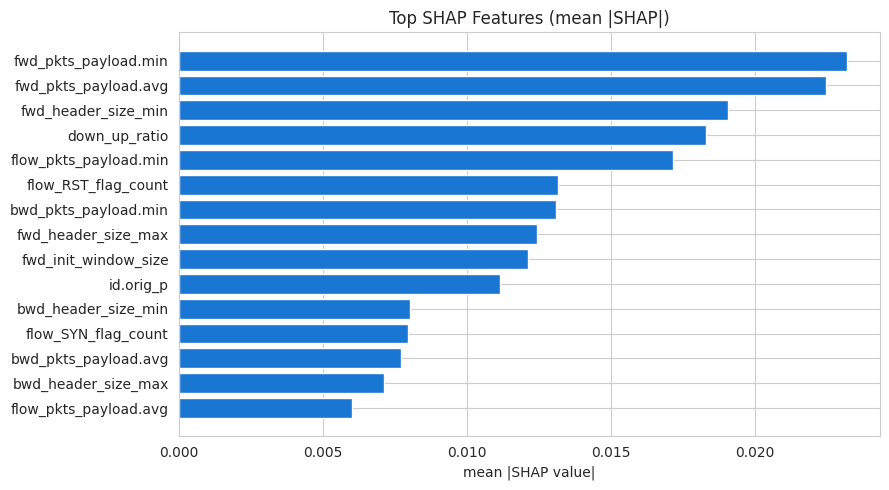

SHAP explanation time: 1670.775s
SHAP summary plot:


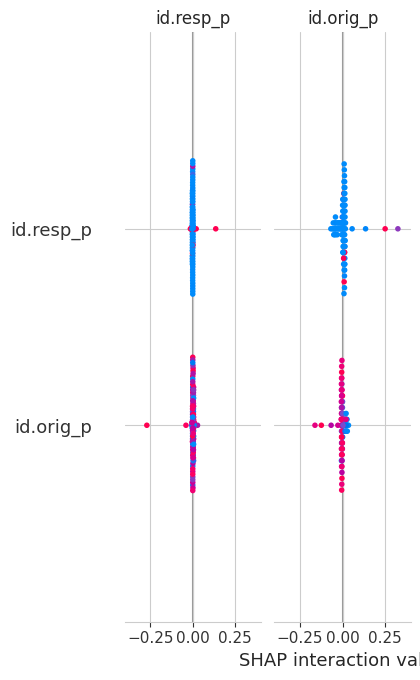

SHAP bar summary plot:


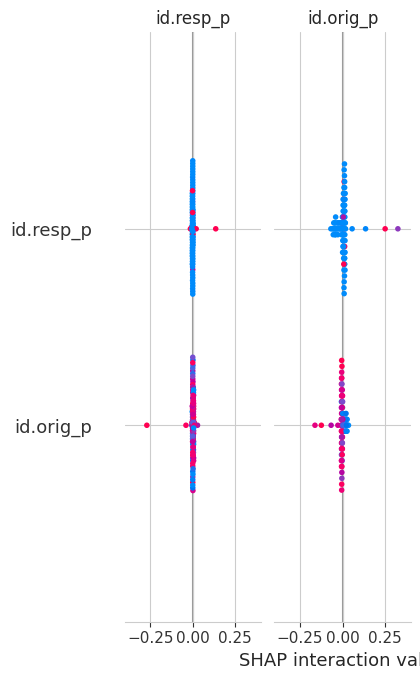

Local SHAP (predicted ATTACK) at sampled index 1


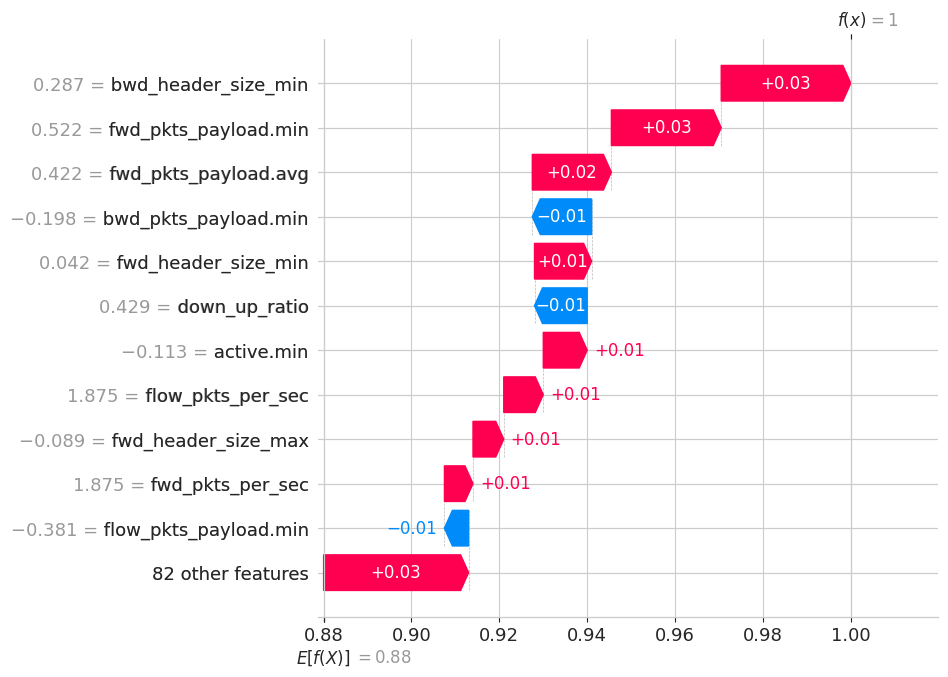

Local SHAP (predicted NORMAL) at sampled index 0


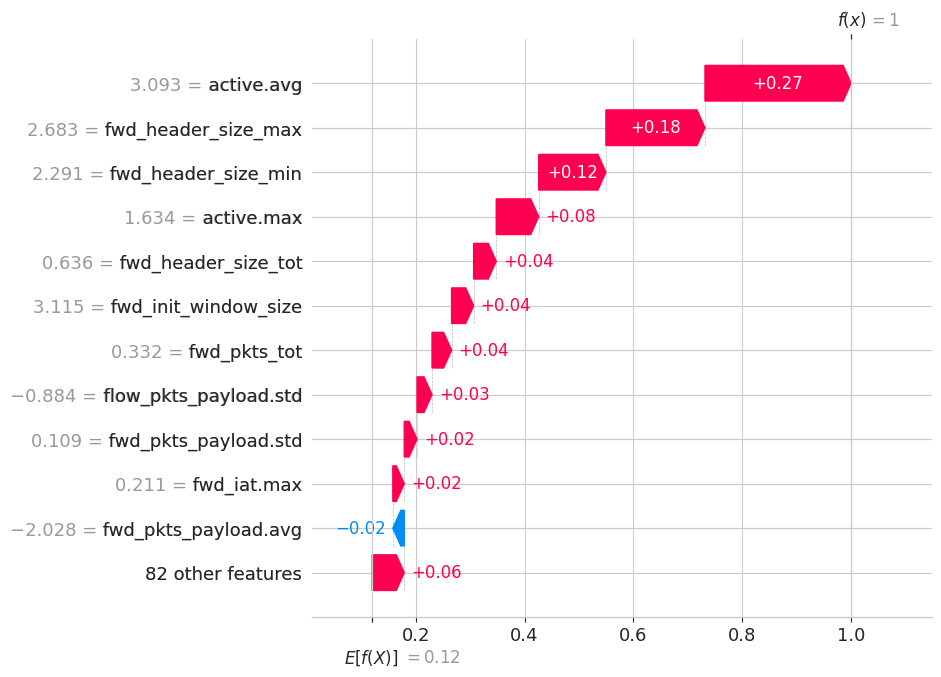

In [11]:
# STEP 2: SHAP global + local analysis and diagrams
# Use real processed feature names when available (same idea as inference_xai).
feature_names = None

if 'INFER_FEATURE_NAMES' in globals() and INFER_FEATURE_NAMES is not None and len(INFER_FEATURE_NAMES) == X_train.shape[1]:
    feature_names = [str(c) for c in INFER_FEATURE_NAMES]
elif hasattr(model, 'feature_names_in_') and len(getattr(model, 'feature_names_in_', [])) == X_train.shape[1]:
    feature_names = [str(c) for c in model.feature_names_in_]
else:
    # Derive processed feature names from preprocessor and raw split columns.
    try:
        # Use the globally defined BASE_DIR
        if 'BASE_DIR' not in globals():
            raise RuntimeError("BASE_DIR is not defined. Please run the 'Paths and Data Loading' cell first.")
        _base = BASE_DIR

        _split_dir = _base / 'splits' / 'RT-IoT2022'

        # 1) direct names file if present
        _fn_path = _split_dir / 'feature_names.csv'
        if _fn_path.exists():
            _loaded_names = pd.read_csv(_fn_path, header=None).squeeze().tolist()
            if len(_loaded_names) == X_train.shape[1]:
                feature_names = [str(c) for c in _loaded_names]

        # 2) derive from fitted preprocessor using raw column order
        if feature_names is None:
            _pp_path = _split_dir / 'preprocessor.pkl'
            _xraw_path = _split_dir / 'X_train.csv'
            if _pp_path.exists() and _xraw_path.exists():
                _pp = joblib.load(_pp_path)
                _raw_cols = pd.read_csv(_xraw_path, nrows=1).columns.tolist()
                try:
                    _derived = _pp.get_feature_names_out(_raw_cols).tolist()
                except Exception:
                    _derived = _pp.get_feature_names_out().tolist()

                if len(_derived) == X_train.shape[1]:
                    feature_names = [str(c) for c in _derived]
    except Exception:
        pass

if feature_names is None:
    raise RuntimeError(
        'Could not resolve exact processed feature names for RT-IoT2022. '
        'Expected one of: INFER_FEATURE_NAMES, model.feature_names_in_, splits/RT-IoT2022/feature_names.csv, '
        'or derivation via splits/RT-IoT2022/preprocessor.pkl + X_train.csv.'
    )

X_train_df = pd.DataFrame(X_train, columns=feature_names)
X_test_df = pd.DataFrame(X_test, columns=feature_names)

bg_size = min(2000, len(X_train_df))
sample_size = min(100, len(X_test_df))
bg_df = X_train_df.sample(bg_size, random_state=42)
X_sample = X_test_df.sample(sample_size, random_state=42)

t0 = time.time()
explainer = shap.Explainer(model.predict_proba, bg_df)
shap_exp = explainer(X_sample)
shap_time = round(time.time() - t0, 3)

sv = np.asarray(shap_exp.values)
# Corrected: Average across samples (axis=0) and classes (axis=2) to get 1D feature importances
mean_abs_shap = np.abs(sv).mean(axis=(0, 2))
shap_top_idx = np.argsort(mean_abs_shap)[::-1][:15]
shap_top_features = [feature_names[i] for i in shap_top_idx]

shap_table = pd.DataFrame({
    'feature': shap_top_features,
    'mean_abs_shap': mean_abs_shap[shap_top_idx]
})
print('Top SHAP features:')
print(shap_table.to_string(index=False))

plt.figure(figsize=(9, 5))
plt.barh(shap_table['feature'][::-1], shap_table['mean_abs_shap'][::-1], color='#1976d2')
plt.title('Top SHAP Features (mean |SHAP|)')
plt.xlabel('mean |SHAP value|')
plt.tight_layout()
plt.show()

print(f'SHAP explanation time: {shap_time}s')
print('SHAP summary plot:')
shap.summary_plot(sv, X_sample, feature_names=feature_names, show=True)

print('SHAP bar summary plot:')
shap.summary_plot(sv, X_sample, feature_names=feature_names, plot_type='bar', show=True)

# Local explanation for one attack and one normal sample
y_pred_sample = model.predict(X_sample)
attack_idx = np.where(y_pred_sample == 1)[0]
normal_idx = np.where(y_pred_sample == 0)[0]

if len(attack_idx) > 0:
    i = int(attack_idx[0])
    print(f'Local SHAP (predicted ATTACK) at sampled index {i}')
    shap.plots.waterfall(shap_exp[i, :, 1], max_display=12)

if len(normal_idx) > 0:
    j = int(normal_idx[0])
    print(f'Local SHAP (predicted NORMAL) at sampled index {j}')
    shap.plots.waterfall(shap_exp[j, :, 0], max_display=12)

# Persist for later cells
XAI_CTX = {
    'feature_names': feature_names,
    'X_train_df': X_train_df,
    'X_test_df': X_test_df,
    'X_sample': X_sample,
    'shap_exp': shap_exp,
    'shap_values': sv,
    'shap_top_features': shap_top_features,
    'shap_time_sec': shap_time,
}

Top candidate SHAP-informed rules:
                           rule  coverage  precision_attack  support
  fwd_pkts_payload.avg > 0.4224  0.008501          0.847134      157
flow_pkts_payload.min > -0.3807  0.171702          0.806686     3171
         down_up_ratio > 0.4290  0.006877          0.787402      127
   flow_RST_flag_count < 0.4640  0.219244          0.739442     4049
   fwd_header_size_min < 0.0416  0.102827          0.677199     1899
         down_up_ratio < 0.4290  0.209552          0.673385     3870
  fwd_pkts_payload.min < 0.5218  0.235001          0.571198     4340
  fwd_pkts_payload.avg < 0.4224  0.227691          0.559572     4205
  fwd_pkts_payload.min > 0.5218  0.001191          0.318182       22
   fwd_header_size_min > 0.0416  0.080897          0.296519     1494
   flow_RST_flag_count > 0.4640  0.011912          0.163636      220
flow_pkts_payload.min < -0.3807  0.000000          0.000000        0


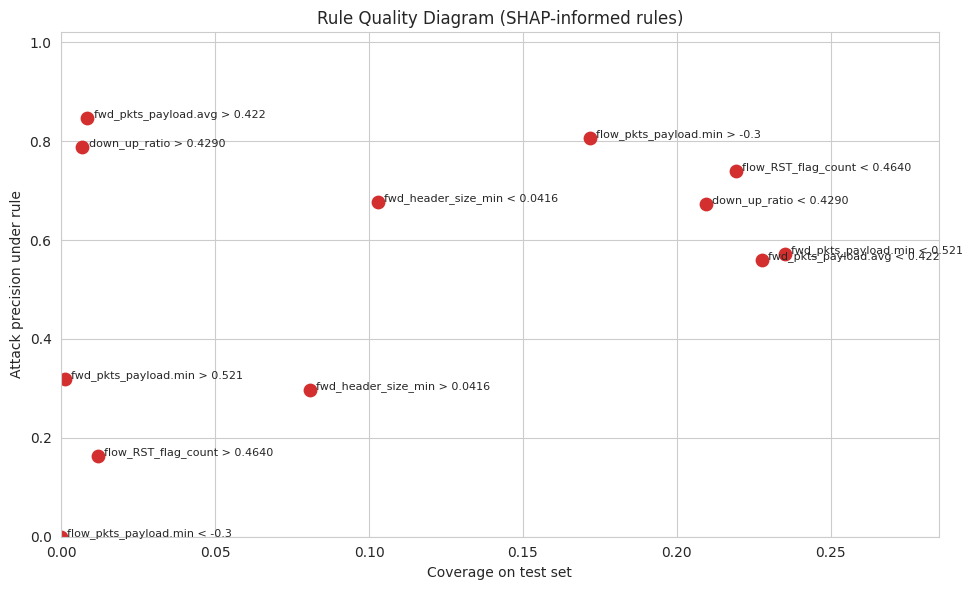


Best rule summary:
  rule: fwd_pkts_payload.avg > 0.4224
  coverage: 0.008501191249729262
  precision_attack: 0.8471337579617835
  support: 157


In [12]:
# STEP 3: SHAP-based manual rule drafting + rule diagrams
if 'XAI_CTX' not in globals():
    raise RuntimeError('Run STEP 2 first.')

X_test_df = XAI_CTX['X_test_df']
feature_names = XAI_CTX['feature_names']
shap_values = XAI_CTX['shap_values'][:, :, 1]
X_sample = XAI_CTX['X_sample']

# Build candidate thresholds from top SHAP features using sampled quantiles.
mean_abs = np.abs(shap_values).mean(axis=0)
top_idx = np.argsort(mean_abs)[::-1][:6]

def eval_rule(mask, y_true):
    coverage = float(mask.mean())
    if mask.sum() == 0:
        return {'coverage': 0.0, 'precision_attack': 0.0, 'support': 0}
    precision_attack = float((y_true[mask] == 1).mean())
    return {
        'coverage': coverage,
        'precision_attack': precision_attack,
        'support': int(mask.sum())
    }

rule_rows = []
y_test_arr = np.asarray(y_test)

for i in top_idx:
    f = feature_names[i]
    q75 = float(X_sample[f].quantile(0.75))
    q25 = float(X_sample[f].quantile(0.25))

    mask_hi = X_test_df[f].values > q75
    mask_lo = X_test_df[f].values < q25

    hi_m = eval_rule(mask_hi, y_test_arr)
    lo_m = eval_rule(mask_lo, y_test_arr)

    rule_rows.append({'rule': f'{f} > {q75:.4f}', **hi_m})
    rule_rows.append({'rule': f'{f} < {q25:.4f}', **lo_m})

rule_df = pd.DataFrame(rule_rows).sort_values(['precision_attack', 'coverage'], ascending=False)
print('Top candidate SHAP-informed rules:')
print(rule_df.head(12).to_string(index=False))

# Plot rule quality diagram (precision vs coverage)
plot_df = rule_df.head(12).copy()
plt.figure(figsize=(10, 6))
plt.scatter(plot_df['coverage'], plot_df['precision_attack'], s=80, c='#d32f2f')
for _, r in plot_df.iterrows():
    plt.text(r['coverage'] + 0.002, r['precision_attack'] + 0.002, r['rule'][:28], fontsize=8)
plt.title('Rule Quality Diagram (SHAP-informed rules)')
plt.xlabel('Coverage on test set')
plt.ylabel('Attack precision under rule')
plt.xlim(0, min(1.0, max(0.05, plot_df['coverage'].max() + 0.05)))
plt.ylim(0, 1.02)
plt.tight_layout()
plt.show()

# Best single rule summary
best_rule = plot_df.iloc[0].to_dict() if len(plot_df) else None
if best_rule:
    print('\nBest rule summary:')
    for k, v in best_rule.items():
        print(f'  {k}: {v}')

XAI_CTX['rule_df'] = rule_df

SHAP analysis metrics:
                      metric       value
               shap_time_sec 1670.775000
    sparsity_top10_mass_mean    0.696366
     fidelity_mae_top10_mask    0.032000
       stability_cosine_mean    0.528495
faithfulness_prob_drop_top10   -0.016000


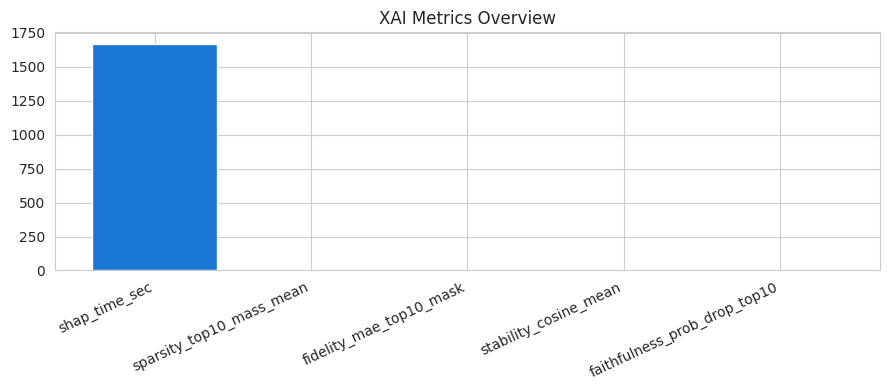

In [13]:
# STEP 4: SHAP analysis metrics (fidelity, stability, sparsity, faithfulness, time)
if 'XAI_CTX' not in globals():
    raise RuntimeError('Run STEP 2 first.')

X_sample = XAI_CTX['X_sample']
TARGET_CLASS = 1  # attack class
shap_values = XAI_CTX['shap_values'][:, :, TARGET_CLASS]
feature_names = XAI_CTX['feature_names']

# Sparsity: concentration of contribution mass in top features
abs_sv = np.abs(shap_values)
frac_top10 = np.sum(np.sort(abs_sv, axis=1)[:, -10:], axis=1) / (np.sum(abs_sv, axis=1) + 1e-12)
sparsity_top10_mean = float(np.mean(frac_top10))

# Fidelity: compare model probability change after masking non-top features
proba_full = model.predict_proba(X_sample)[:, 1]
topk = 10
masked = np.zeros_like(X_sample.values)
for r in range(X_sample.shape[0]):
    idx = np.argsort(abs_sv[r])[::-1][:topk]
    masked[r, idx] = X_sample.values[r, idx]
proba_masked = model.predict_proba(masked)[:, 1]
fidelity_mae = float(np.mean(np.abs(proba_full - proba_masked)))

# Stability: SHAP similarity for neighboring samples
sub_n = min(300, X_sample.shape[0])
sub_idx = np.random.choice(X_sample.shape[0], size=sub_n, replace=False)
X_sub = X_sample.iloc[sub_idx].reset_index(drop=True)
sv_sub = shap_values[sub_idx]

dists = np.linalg.norm(X_sub.values[:, None, :] - X_sub.values[None, :, :], axis=2)
np.fill_diagonal(dists, np.inf)
nn = np.argmin(dists, axis=1)

cos_sims = []
for i in range(sub_n):
    a = sv_sub[i]
    b = sv_sub[nn[i]]
    denom = (np.linalg.norm(a) * np.linalg.norm(b)) + 1e-12
    cos_sims.append(float(np.dot(a, b) / denom))
stability_cos_mean = float(np.mean(cos_sims))

# Faithfulness: remove top-k SHAP features and measure probability drop
ablated = X_sample.values.copy()
for r in range(X_sample.shape[0]):
    idx = np.argsort(abs_sv[r])[::-1][:topk]
    ablated[r, idx] = 0.0
proba_ablated = model.predict_proba(ablated)[:, 1]
faithfulness_drop = float(np.mean(proba_full - proba_ablated))

metrics_df = pd.DataFrame([
    {'metric': 'shap_time_sec', 'value': XAI_CTX.get('shap_time_sec', np.nan)},
    {'metric': 'sparsity_top10_mass_mean', 'value': sparsity_top10_mean},
    {'metric': 'fidelity_mae_top10_mask', 'value': fidelity_mae},
    {'metric': 'stability_cosine_mean', 'value': stability_cos_mean},
    {'metric': 'faithfulness_prob_drop_top10', 'value': faithfulness_drop},
])

print('SHAP analysis metrics:')
print(metrics_df.to_string(index=False))

plt.figure(figsize=(9, 4))
plt.bar(metrics_df['metric'], metrics_df['value'], color=['#1976d2', '#43a047', '#fb8c00', '#8e24aa', '#e53935'])
plt.xticks(rotation=25, ha='right')
plt.title('XAI Metrics Overview')
plt.tight_layout()
plt.show()

XAI_CTX['metrics_df'] = metrics_df


LIME explanation (attack_like) at sampled index 1:
                         rule    weight
 flow_CWR_flag_count <= -0.02  0.600782
    fwd_bulk_packets <= -0.02  0.573984
 flow_ECE_flag_count <= -0.02  0.513829
          active.std <= -0.01  0.145038
            idle.std <= -0.04  0.123100
 flow_FIN_flag_count <= -0.24  0.115517
bwd_pkts_payload.min <= -0.20  0.111317
           proto_icmp <= 0.00  0.107439
          service_irc <= 0.00 -0.022843
      bwd_bulk_bytes <= -0.01 -0.038278
 fwd_pkts_payload.avg <= 0.42 -0.053728
         service_dhcp <= 0.00 -0.066289


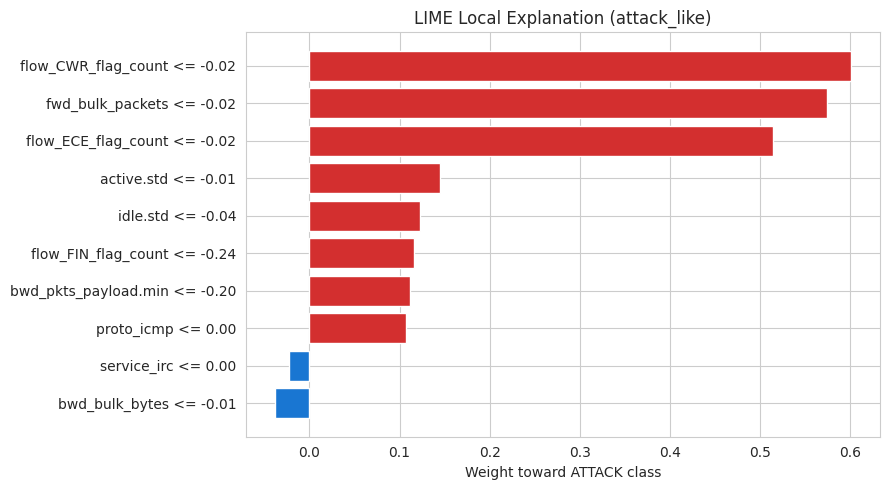


LIME explanation (normal_like) at sampled index 0:
                         rule    weight
    fwd_bulk_packets <= -0.02  0.675976
 flow_ECE_flag_count <= -0.02  0.207173
 flow_CWR_flag_count <= -0.02  0.160388
          active.std <= -0.01  0.120747
bwd_pkts_payload.min <= -0.20  0.112305
 flow_FIN_flag_count <= -0.24  0.101722
           proto_icmp <= 0.00  0.042601
          service_ntp <= 0.00 -0.009949
         service_dhcp <= 0.00 -0.020892
        down_up_ratio <= 0.43 -0.043025
 bwd_init_window_size > -0.27 -0.054090
  fwd_URG_flag_count <= -0.13 -0.056392


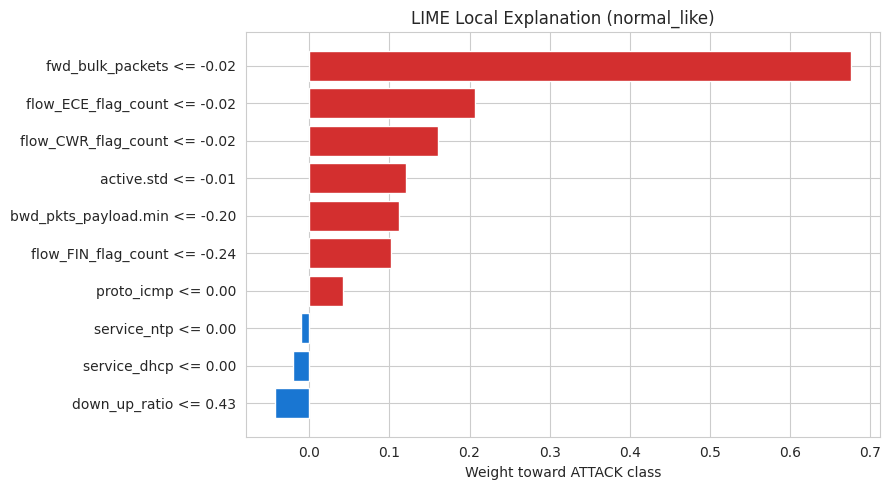


Aggregated LIME rule importance (mean |weight| across explained samples):
                         rule  abs_weight
    fwd_bulk_packets <= -0.02    0.624980
 flow_CWR_flag_count <= -0.02    0.380585
 flow_ECE_flag_count <= -0.02    0.360501
          active.std <= -0.01    0.132893
            idle.std <= -0.04    0.123100
bwd_pkts_payload.min <= -0.20    0.111811
 flow_FIN_flag_count <= -0.24    0.108619
           proto_icmp <= 0.00    0.075020
  fwd_URG_flag_count <= -0.13    0.056392
 bwd_init_window_size > -0.27    0.054090
 fwd_pkts_payload.avg <= 0.42    0.053728
         service_dhcp <= 0.00    0.043590


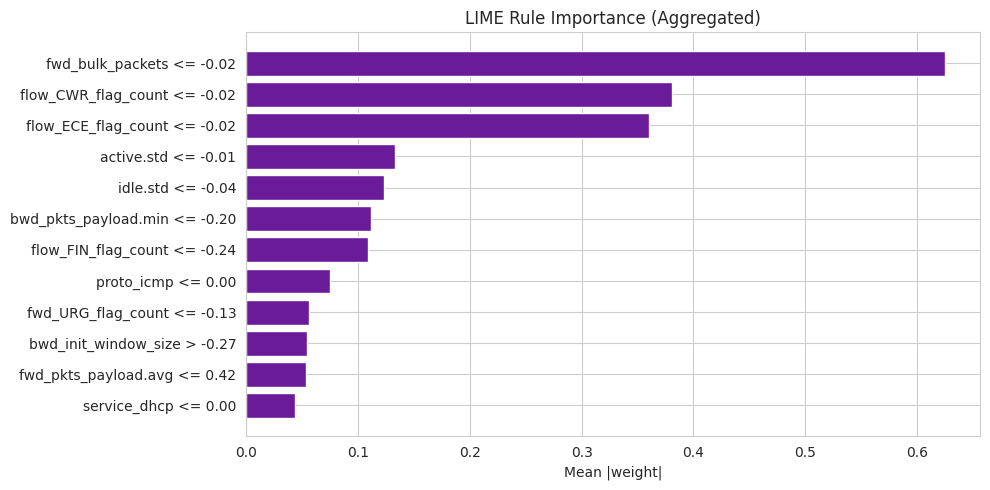

In [14]:
# STEP 5: LIME local explanations + diagrams
if 'XAI_CTX' not in globals():
    raise RuntimeError('Run STEP 2 first.')

X_train_df = XAI_CTX['X_train_df']
X_sample = XAI_CTX['X_sample']
feature_names = XAI_CTX['feature_names']

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_df.values,
    feature_names=feature_names,
    class_names=['normal', 'attack'],
    mode='classification',
    discretize_continuous=True,
    random_state=42
)

# Explain one predicted attack and one predicted normal sample.
preds = model.predict(X_sample)
attack_ix = np.where(preds == 1)[0]
normal_ix = np.where(preds == 0)[0]
chosen = []
if len(attack_ix) > 0:
    chosen.append(('attack_like', int(attack_ix[0])))
if len(normal_ix) > 0:
    chosen.append(('normal_like', int(normal_ix[0])))
if not chosen:
    chosen.append(('fallback', 0))

lime_rows = []
for tag, idx in chosen:
    exp = lime_explainer.explain_instance(
        X_sample.iloc[idx].values,
        model.predict_proba,
        num_features=12
    )
    pairs = exp.as_list(label=1)

    local_df = pd.DataFrame(pairs, columns=['rule', 'weight']).sort_values('weight', ascending=False)
    print(f'\nLIME explanation ({tag}) at sampled index {idx}:')
    print(local_df.to_string(index=False))

    plt.figure(figsize=(9, 5))
    plot_df = local_df.head(10).iloc[::-1]
    colors = ['#d32f2f' if w > 0 else '#1976d2' for w in plot_df['weight']]
    plt.barh(plot_df['rule'], plot_df['weight'], color=colors)
    plt.title(f'LIME Local Explanation ({tag})')
    plt.xlabel('Weight toward ATTACK class')
    plt.tight_layout()
    plt.show()

    for r, w in pairs:
        lime_rows.append({'sample_tag': tag, 'rule': r, 'weight': float(w)})

lime_df = pd.DataFrame(lime_rows)
agg_lime = (lime_df.assign(abs_weight=lambda d: d['weight'].abs())
                  .groupby('rule', as_index=False)['abs_weight']
                  .mean()
                  .sort_values('abs_weight', ascending=False)
                  .head(12))

print('\nAggregated LIME rule importance (mean |weight| across explained samples):')
print(agg_lime.to_string(index=False))

plt.figure(figsize=(10, 5))
plt.barh(agg_lime['rule'][::-1], agg_lime['abs_weight'][::-1], color='#6a1b9a')
plt.title('LIME Rule Importance (Aggregated)')
plt.xlabel('Mean |weight|')
plt.tight_layout()
plt.show()

XAI_CTX['lime_df'] = lime_df

In [15]:
# STEP 6: Final XAI summary table
if 'XAI_CTX' not in globals():
    raise RuntimeError('Run STEP 2 first.')

metrics_df = XAI_CTX.get('metrics_df', pd.DataFrame(columns=['metric', 'value']))
rule_df = XAI_CTX.get('rule_df', pd.DataFrame())
lime_df = XAI_CTX.get('lime_df', pd.DataFrame())

best_rule = None
if len(rule_df) > 0:
    best_rule = rule_df.sort_values(['precision_attack', 'coverage'], ascending=False).iloc[0]

summary_rows = [
    {'item': 'model', 'value': MODEL_NAME if 'MODEL_NAME' in globals() else 'DecisionTree'},
    {'item': 'dataset', 'value': 'RT-IoT2022'},
    {'item': 'xai_samples_shap', 'value': len(XAI_CTX.get('X_sample', []))},
    {'item': 'shap_top_feature_1', 'value': (XAI_CTX.get('shap_top_features') or ['NA'])[0]},
    {'item': 'lime_rules_collected', 'value': int(len(lime_df))},
]

if best_rule is not None:
    summary_rows.extend([
        {'item': 'best_rule', 'value': best_rule['rule']},
        {'item': 'best_rule_precision_attack', 'value': round(float(best_rule['precision_attack']), 6)},
        {'item': 'best_rule_coverage', 'value': round(float(best_rule['coverage']), 6)},
    ])

for _, r in metrics_df.iterrows():
    summary_rows.append({'item': r['metric'], 'value': round(float(r['value']), 6)})

xai_summary = pd.DataFrame(summary_rows)
print('Final XAI summary:')
print(xai_summary.to_string(index=False))

# Optional save for client reporting
xai_summary.to_csv(f"{RESULT_DIR}//{ARTIFACT_NAME}_xai_summary.csv", index=False)
print(f'\nSaved: {RESULT_DIR}//{ARTIFACT_NAME}_xai_summary.csv')

Final XAI summary:
                        item                         value
                       model                           KNN
                     dataset                    RT-IoT2022
            xai_samples_shap                           100
          shap_top_feature_1          fwd_pkts_payload.min
        lime_rules_collected                            24
                   best_rule fwd_pkts_payload.avg > 0.4224
  best_rule_precision_attack                      0.847134
          best_rule_coverage                      0.008501
               shap_time_sec                      1670.775
    sparsity_top10_mass_mean                      0.696366
     fidelity_mae_top10_mask                         0.032
       stability_cosine_mean                      0.528495
faithfulness_prob_drop_top10                        -0.016

Saved: /content/drive/MyDrive/MLmodeling/XAI/results/RT-IoT2022//RT_10_KNN_xai_summary.csv
